# Install Libraries

In [14]:
%pip install pyspark numpy pandas seaborn matplotlib findspark

Note: you may need to restart the kernel to use updated packages.


# Setup Spark Session

In [15]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Enterprise Fraud Detection System") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .master("local[*]") \
    .getOrCreate()

print(f"🚀 Spark UI is running at: {spark.sparkContext.uiWebUrl}")
print(f"Spark Version: {spark.version}")

🚀 Spark UI is running at: http://host.docker.internal:4040
Spark Version: 4.1.1


# Load Data & Schema

In [16]:
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType, StringType

schema = StructType([
    StructField("Time", DoubleType(), True),
    *[StructField(f"V{i}", DoubleType(), True) for i in range(1, 29)],
    StructField("Amount", DoubleType(), True),
    StructField("Class", IntegerType(), True)
])

# Load Data
df = spark.read.csv("dataset/creditcard.csv", header=True, schema=schema)

print("Data Loaded Successfully")
print(f"Total Transactions: {df.count():,}")
df.printSchema()

Data Loaded Successfully
Total Transactions: 284,807
root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- 

# Data Exploration (Visualization)

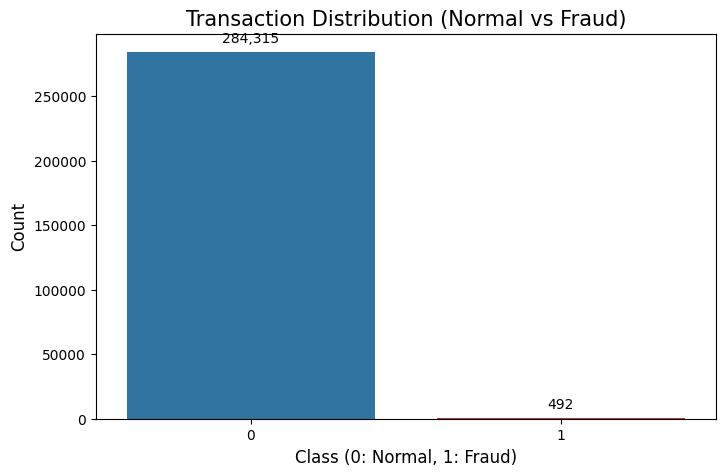

Fraud Ratio: 0.1727% (ข้อมูล Imbalance มาก!)


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fraud_count = df.groupBy("Class").count().toPandas()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x="Class", 
    y="count", 
    data=fraud_count, 
    hue="Class",      
    legend=False,    
    palette=["#1f77b4", "#d62728"]
)

plt.title("Transaction Distribution (Normal vs Fraud)", fontsize=15)
plt.xlabel("Class (0: Normal, 1: Fraud)", fontsize=12)
plt.ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

# คำนวณ Ratio
total = fraud_count['count'].sum()
fraud = fraud_count[fraud_count['Class'] == 1]['count'].values[0]
print(f"Fraud Ratio: {fraud/total*100:.4f}% (ข้อมูล Imbalance มาก!)")

# Building ML Pipeline

In [19]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.classification import RandomForestClassifier

feature_cols = [f"V{i}" for i in range(1, 29)] + ["Amount"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")

scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)

rf = RandomForestClassifier(labelCol="Class", featuresCol="scaled_features", numTrees=50, maxDepth=10, seed=42)

pipeline = Pipeline(stages=[assembler, scaler, rf])

print("ML Pipeline Constructed")

ML Pipeline Constructed


# Train-Test Split & Execution

In [20]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

print(f"Training Data: {train_data.count():,} rows")
print(f"Testing Data: {test_data.count():,} rows")

print("Training Model... (Please wait)")
model = pipeline.fit(train_data)

print("Model Trained Successfully!")

Training Data: 228,162 rows
Testing Data: 56,645 rows
Training Model... (Please wait)
Model Trained Successfully!


# Evaluation

Note: you may need to restart the kernel to use updated packages.
FINAL RESULTS (Spark Evaluator)
Accuracy:           0.9993
Weighted F1 Score:  0.9992
Weighted Precision: 0.9993
Weighted Recall:    0.9993

Generating Confusion Matrix...

Confusion Matrix:
[[56539     6]
 [   34    66]]


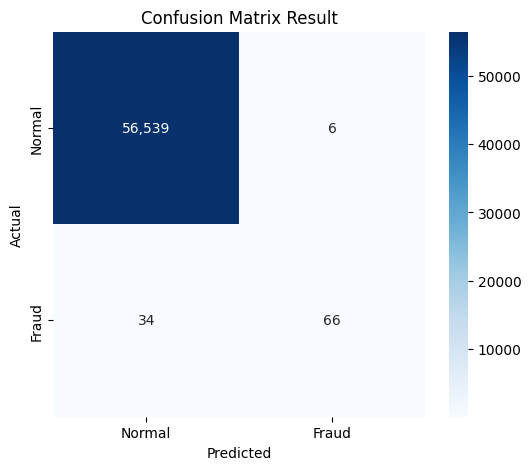


Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56545
       Fraud       0.92      0.66      0.77       100

    accuracy                           1.00     56645
   macro avg       0.96      0.83      0.88     56645
weighted avg       1.00      1.00      1.00     56645



In [21]:
%pip install scikit-learn seaborn matplotlib

predictions = model.transform(test_data)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

evaluator = MulticlassClassificationEvaluator(labelCol="Class", predictionCol="prediction")

accuracy = evaluator.setMetricName("accuracy").evaluate(predictions)
f1 = evaluator.setMetricName("f1").evaluate(predictions)
weighted_precision = evaluator.setMetricName("weightedPrecision").evaluate(predictions)
weighted_recall = evaluator.setMetricName("weightedRecall").evaluate(predictions)

print("="*30)
print("FINAL RESULTS (Spark Evaluator)")
print("="*30)
print(f"Accuracy:           {accuracy:.4f}")
print(f"Weighted F1 Score:  {f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")

print("\nGenerating Confusion Matrix...")

pandas_df = predictions.select("Class", "prediction").toPandas()

y_true = pandas_df["Class"]
y_pred = pandas_df["prediction"]

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Result')
plt.show()

print("\nDetailed Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))

In [11]:
spark.stop()